# Workshop 9: Logistic Regression & Classification Fundamentals

---

## Why Classification?

In the previous workshops (1–7) we covered data preprocessing and feature engineering. In Workshop 8 we studied **linear regression**, which predicts a continuous output (e.g., house prices, temperatures). Now we tackle a fundamentally different problem: **classification** — predicting a *discrete category* for each input.

### Real-World Examples

| Domain | Input Features | Output Class |
|---|---|---|
| **Medical diagnosis** | Cell measurements, imaging features | Malignant / Benign |
| **Spam detection** | Email text, metadata | Spam / Not Spam |
| **Fraud detection** | Transaction amount, location, time | Fraudulent / Legitimate |
| **Credit scoring** | Income, debt, history | Default / No Default |
| **Image recognition** | Pixel values | Cat / Dog / Car / ... |

Notice that the output is no longer a number on a continuous scale — it is a **label**. This changes everything about how we model the problem.

---

## Learning Objectives

By the end of this workshop, you will be able to:

1. **Explain** why linear regression is unsuitable for classification tasks and how logistic regression addresses this.
2. **Derive and implement** the sigmoid function, the logistic regression model, and the binary cross-entropy (log-loss) cost function.
3. **Implement logistic regression from scratch** using gradient descent in NumPy, and verify it against scikit-learn.
4. **Evaluate classifiers** using confusion matrices, accuracy, precision, recall, F1-score, ROC curves, and AUC.
5. **Apply regularization** (L1/L2) to logistic regression and understand its effect on model complexity.

## Theory — From Linear to Logistic Regression

### Why Not Use Linear Regression for Classification?

Recall from Workshop 8 that linear regression outputs:

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b$$

This output is **unbounded**: $\hat{y} \in (-\infty, +\infty)$. For binary classification we want the model to output a **probability** $P(y=1 \mid \mathbf{x}) \in [0, 1]$. Using raw linear output as a probability is problematic:

- Predictions can exceed 1 or go below 0 — meaningless as probabilities.
- The 0/1 labels create a non-linear relationship that a line fits poorly.
- The outliers in one class can drastically shift the fitted line and move the decision boundary.

### The Sigmoid (Logistic) Function

We need a function that **squashes** any real number into $(0, 1)$. The sigmoid function does exactly this:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Key properties:**

| Input $z$ | $\sigma(z)$ | Interpretation |
|---|---|---|
| $z \to -\infty$ | $\sigma(z) \to 0$ | Strong evidence for class 0 |
| $z = 0$ | $\sigma(0) = 0.5$ | Total uncertainty |
| $z \to +\infty$ | $\sigma(z) \to 1$ | Strong evidence for class 1 |

Its derivative has a beautiful closed form:

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

This property makes gradient computation very efficient.

## Theory — The Logistic Regression Model

### Model Definition

Logistic regression applies the sigmoid function to the linear combination of features:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

where $\mathbf{w} \in \mathbb{R}^d$ are the weights and $b \in \mathbb{R}$ is the bias.

### Decision Boundary

We classify a point as class 1 if $P(y=1 \mid \mathbf{x}) \geq 0.5$, which corresponds to:

$$\mathbf{w}^T \mathbf{x} + b \geq 0$$

The **decision boundary** is the hyperplane $\mathbf{w}^T \mathbf{x} + b = 0$. Points on one side are classified as class 1, points on the other side as class 0.

### Log-Odds (Logit) Interpretation

Let $p = P(y=1 \mid \mathbf{x})$. Then we can show:

$$\log\left(\frac{p}{1-p}\right) = \mathbf{w}^T \mathbf{x} + b$$

The left-hand side is the **log-odds** or **logit** — the logarithm of the ratio of the probability of the event occurring to it not occurring. This is why the model is called **logistic** regression: it is a linear model for the *logit* of the probability. The weights $w_j$ can be interpreted as: "a unit increase in $x_j$ increases the log-odds by $w_j$."

## Theory — Log-Loss (Binary Cross-Entropy)

### Why Not Use MSE for Classification?

If we plug the sigmoid output into the Mean Squared Error loss:

$$J_{MSE}(\mathbf{w}) = \frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b))^2$$

the resulting cost function is **non-convex** — it has many local minima, making gradient descent unreliable. We need a better loss.

### The Log-Loss (Binary Cross-Entropy)

Derived from maximum likelihood estimation, the log-loss for a single example is:

$$\mathcal{L}(\hat{p}, y) = -\left[y \log(\hat{p}) + (1-y) \log(1 - \hat{p})\right]$$

**Intuition:**
- If $y=1$ and $\hat{p} \to 1$: loss $\to 0$ (correct and confident — good!)
- If $y=1$ and $\hat{p} \to 0$: loss $\to +\infty$ (wrong and confident — severely penalized!)
- If $y=0$ and $\hat{p} \to 0$: loss $\to 0$ (correct and confident — good!)
- If $y=0$ and $\hat{p} \to 1$: loss $\to +\infty$ (wrong and confident — severely penalized!)

### Cost Function Over the Full Dataset

The average log-loss over $m$ training examples:

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[y^{(i)} \log(\hat{p}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)})\right]$$

This function is **convex** when composed with the sigmoid — gradient descent will converge to the global minimum.

## Theory — Gradient Descent for Logistic Regression

### Computing the Gradient

To minimize $J(\mathbf{w}, b)$, we need its gradient with respect to $\mathbf{w}$ and $b$. With $\hat{\mathbf{p}} = \sigma(\mathbf{X}\mathbf{w} + b)$, the gradients are:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{p}} - \mathbf{y})$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{p}^{(i)} - y^{(i)})$$

### Remarkable Similarity to Linear Regression

Compare with the gradient for linear regression (Workshop 8):

$$\frac{\partial J_{MSE}}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$

The form is **identical** — the only difference is that $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$ for linear regression, whereas $\hat{\mathbf{p}} = \sigma(\mathbf{X}\mathbf{w} + b)$ for logistic regression. This is not a coincidence: both models belong to the **Generalized Linear Models (GLM)** family.

### Update Rules

At each iteration, we update the parameters:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial J}{\partial \mathbf{w}} = \mathbf{w} - \frac{\eta}{m} \mathbf{X}^T (\hat{\mathbf{p}} - \mathbf{y})$$

$$b \leftarrow b - \eta \cdot \frac{\partial J}{\partial b} = b - \frac{\eta}{m} \sum_{i=1}^{m}(\hat{p}^{(i)} - y^{(i)})$$

where $\eta$ (eta) is the **learning rate**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from scipy.special import expit  # sigmoid function

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("All imports successful.")

All imports successful.


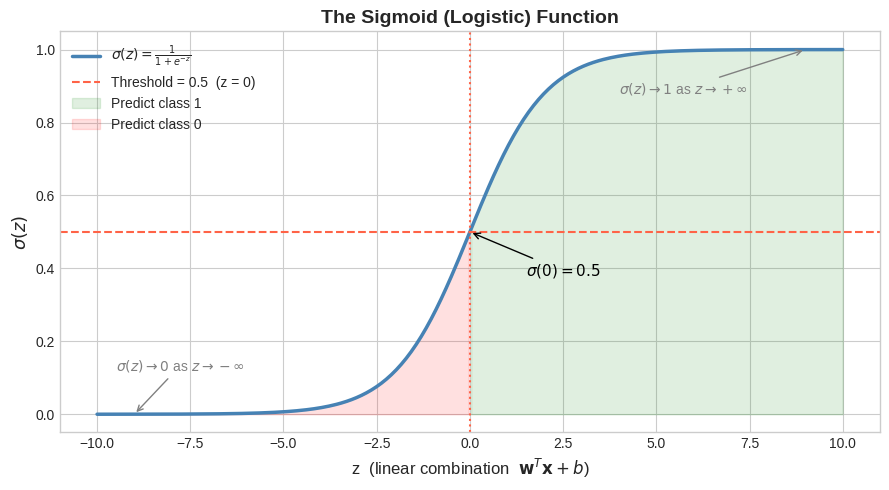

In [2]:
# --- Visualize the Sigmoid Function ---

z = np.linspace(-10, 10, 300)
sigmoid_z = expit(z)  # scipy's numerically stable sigmoid

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(z, sigmoid_z, color='steelblue', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')

# Highlight threshold at 0.5
ax.axhline(y=0.5, color='tomato', linestyle='--', linewidth=1.5, label='Threshold = 0.5  (z = 0)')
ax.axvline(x=0, color='tomato', linestyle=':', linewidth=1.5)

# Annotate key points
ax.annotate(r'$\sigma(0) = 0.5$', xy=(0, 0.5), xytext=(1.5, 0.38),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'),
            color='black')
ax.annotate(r'$\sigma(z) \to 1$ as $z \to +\infty$', xy=(9, 0.9999), xytext=(4, 0.88),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
ax.annotate(r'$\sigma(z) \to 0$ as $z \to -\infty$', xy=(-9, 0.0001), xytext=(-9.5, 0.12),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')

# Shade class regions
ax.fill_between(z, 0, sigmoid_z, where=(z >= 0), alpha=0.12, color='green', label='Predict class 1')
ax.fill_between(z, 0, sigmoid_z, where=(z < 0),  alpha=0.12, color='red',   label='Predict class 0')

ax.set_xlabel('z  (linear combination  $\\mathbf{w}^T\\mathbf{x} + b$)', fontsize=12)
ax.set_ylabel(r'$\sigma(z)$', fontsize=13)
ax.set_title('The Sigmoid (Logistic) Function', fontsize=14, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

 Dataset shape  : (569, 30)  (569 samples, 30 features)
 Target classes : ['malignant' 'benign']

Class distribution:
diagnosis
Benign       357
Malignant    212

Class balance — Benign: 62.7%   Malignant: 37.3%

First 5 rows (selected features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,Malignant



Basic statistics (first 5 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096
std,3.524,4.301,24.299,351.914,0.014
min,6.981,9.710,43.790,143.500,0.053
25%,11.700,16.170,75.170,420.300,0.086
50%,13.370,18.840,86.240,551.100,0.096
75%,15.780,21.800,104.100,782.700,0.105
max,28.110,39.280,188.500,2501.000,0.163


/tmp/ipykernel_2023008/1244430335.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette=['tomato', 'steelblue'], ax=axes[0])


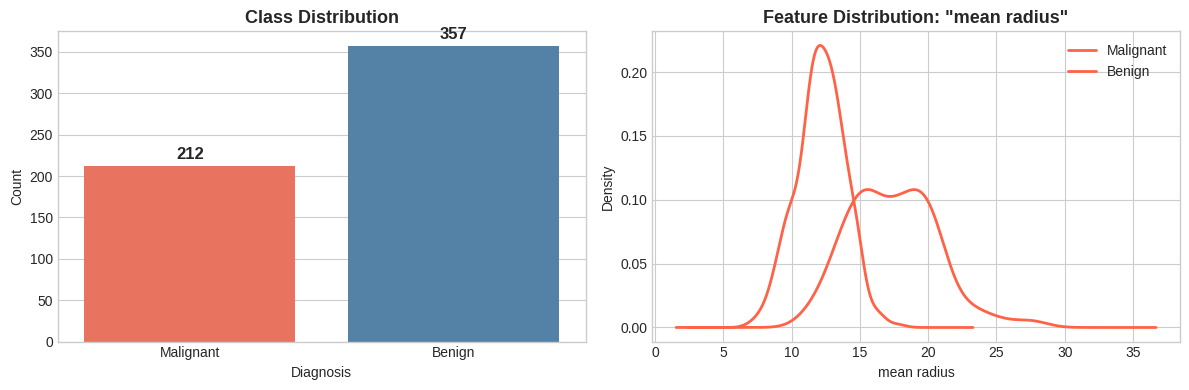

In [3]:
# --- Load the Breast Cancer Wisconsin Dataset & EDA ---

data = load_breast_cancer()
X_raw = data.data
y_raw = data.target  # 0 = malignant, 1 = benign
feature_names = data.feature_names
target_names  = data.target_names   # ['malignant', 'benign']

df = pd.DataFrame(X_raw, columns=feature_names)
df['target'] = y_raw
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("=" * 55)
print(f" Dataset shape  : {X_raw.shape}  ({X_raw.shape[0]} samples, {X_raw.shape[1]} features)")
print(f" Target classes : {target_names}")
print("=" * 55)
print("\nClass distribution:")
counts = df['diagnosis'].value_counts()
print(counts.to_string())
print(f"\nClass balance — Benign: {counts['Benign']/len(df)*100:.1f}%   "
      f"Malignant: {counts['Malignant']/len(df)*100:.1f}%")

print("\nFirst 5 rows (selected features):")
display(df[list(feature_names[:6]) + ['diagnosis']].head())

print("\nBasic statistics (first 5 features):")
display(df[list(feature_names[:5])].describe().round(3))

# Class distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
sns.countplot(data=df, x='diagnosis', palette=['tomato', 'steelblue'], ax=axes[0])
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=12, fontweight='bold')

# Feature distributions for a few features
feat = 'mean radius'
df.groupby('diagnosis')[feat].plot(kind='kde', ax=axes[1],
                                    color=['tomato', 'steelblue'],
                                    linewidth=2)
axes[1].set_title(f'Feature Distribution: "{feat}"', fontsize=13, fontweight='bold')
axes[1].set_xlabel(feat)
axes[1].legend(['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

In [4]:
# --- Preprocessing: Scaling + Stratified Train/Test Split ---
# As covered in Workshops 1-7: features have very different scales,
# so StandardScaler is essential before gradient-based methods.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw    # preserve class proportions in both splits
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # fit on train only!
X_test  = scaler.transform(X_test_raw)       # apply same transform to test

print("Train set:", X_train.shape, "| Test set:", X_test.shape)

# Verify stratification preserved class balance
train_benign_pct = np.mean(y_train == 1) * 100
test_benign_pct  = np.mean(y_test  == 1) * 100
print(f"\nClass balance (Benign %)")
print(f"  Full dataset : {np.mean(y_raw == 1)*100:.1f}%")
print(f"  Train set    : {train_benign_pct:.1f}%")
print(f"  Test set     : {test_benign_pct:.1f}%")
print("\nStratification preserved class proportions. ✓")

Train set: (455, 30) | Test set: (114, 30)

Class balance (Benign %)
  Full dataset : 62.7%
  Train set    : 62.6%
  Test set     : 63.2%

Stratification preserved class proportions. ✓


In [5]:
# --- Logistic Regression From Scratch (NumPy) ---

class LogisticRegressionScratch:
    """
    Binary Logistic Regression trained via batch gradient descent.
    Uses binary cross-entropy (log-loss) as the cost function.
    """

    def __init__(self, lr=0.1, n_iter=1000):
        """
        Parameters
        ----------
        lr     : float — learning rate (step size for gradient descent)
        n_iter : int   — number of gradient descent iterations
        """
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None    # shape: (n_features,)
        self.bias = None       # scalar
        self.loss_history = [] # track log-loss per iteration

    def _sigmoid(self, z):
        """
        Numerically stable sigmoid: clips z to avoid overflow in exp.
        Returns sigma(z) = 1 / (1 + exp(-z)).
        """
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def _compute_loss(self, p, y):
        """
        Binary cross-entropy loss.
        J = -1/m * sum[ y*log(p) + (1-y)*log(1-p) ]
        Clipping p prevents log(0).
        """
        m = len(y)
        p = np.clip(p, 1e-15, 1 - 1e-15)  # numerical stability
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def fit(self, X, y):
        """
        Train the model using batch gradient descent.

        Parameters
        ----------
        X : np.ndarray of shape (m, n_features) — feature matrix
        y : np.ndarray of shape (m,)             — binary labels {0, 1}
        """
        m, n = X.shape

        # Initialize weights to zero (logistic regression converges from zero)
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.loss_history = []

        for iteration in range(self.n_iter):
            # --- Forward pass ---
            z = X @ self.weights + self.bias   # linear combination, shape (m,)
            p = self._sigmoid(z)               # predicted probabilities, shape (m,)

            # --- Compute and store loss ---
            loss = self._compute_loss(p, y)
            self.loss_history.append(loss)

            # --- Backward pass (gradients) ---
            error = p - y                         # residuals, shape (m,)
            grad_w = (X.T @ error) / m            # dJ/dw, shape (n,)
            grad_b = np.mean(error)               # dJ/db, scalar

            # --- Parameter update ---
            self.weights -= self.lr * grad_w
            self.bias    -= self.lr * grad_b

        return self

    def predict_proba(self, X):
        """
        Returns P(y=1 | X) for each sample.
        """
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """
        Returns binary class predictions.
        threshold : float — probability cutoff (default 0.5)
        """
        return (self.predict_proba(X) >= threshold).astype(int)


print("LogisticRegressionScratch class defined.")

LogisticRegressionScratch class defined.


Scratch model — Test Accuracy: 97.37%
Final training log-loss: 0.0566


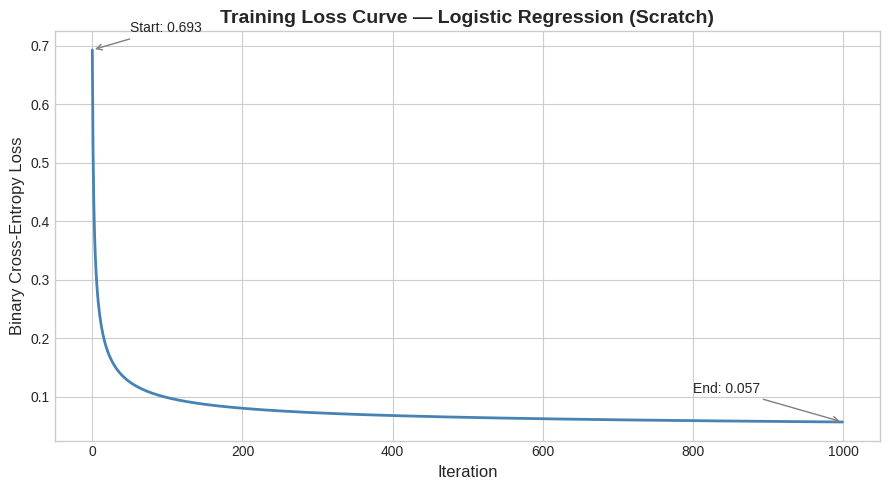

In [6]:
# --- Train Scratch Model & Plot Loss Curve ---

scratch_model = LogisticRegressionScratch(lr=0.1, n_iter=1000)
scratch_model.fit(X_train, y_train)

# Training accuracy
y_pred_scratch = scratch_model.predict(X_test)
acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"Scratch model — Test Accuracy: {acc_scratch*100:.2f}%")
print(f"Final training log-loss: {scratch_model.loss_history[-1]:.4f}")

# Plot loss curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(scratch_model.loss_history, color='steelblue', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss Curve — Logistic Regression (Scratch)', fontsize=14, fontweight='bold')

# Annotate start and end
ax.annotate(f"Start: {scratch_model.loss_history[0]:.3f}",
            xy=(0, scratch_model.loss_history[0]),
            xytext=(50, scratch_model.loss_history[0] + 0.03),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f"End: {scratch_model.loss_history[-1]:.3f}",
            xy=(999, scratch_model.loss_history[-1]),
            xytext=(800, scratch_model.loss_history[-1] + 0.05),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

In [7]:
# --- Train sklearn LogisticRegression & Compare ---

sk_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
sk_model.fit(X_train, y_train)

y_pred_sk = sk_model.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)

print("=" * 45)
print(f" {'Model':<30} {'Accuracy':>10}")
print("=" * 45)
print(f" {'LogisticRegressionScratch':<30} {acc_scratch*100:>9.2f}%")
print(f" {'sklearn LogisticRegression':<30} {acc_sk*100:>9.2f}%")
print("=" * 45)

# Cross-validation score for sklearn model
cv_scores = cross_val_score(sk_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nsklearn 5-fold CV accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

 Model                            Accuracy
 LogisticRegressionScratch          97.37%
 sklearn LogisticRegression         98.25%

sklearn 5-fold CV accuracy: 98.02% ± 1.28%


## Theory — Classification Metrics

Accuracy alone is often insufficient to evaluate a classifier. We need a richer set of metrics, especially when classes are imbalanced.

### The Confusion Matrix

For binary classification, all predictions fall into one of four cells:

|  | **Predicted Positive** | **Predicted Negative** |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

- **TP**: Correctly predicted positive (e.g., cancer correctly identified)
- **TN**: Correctly predicted negative (e.g., healthy correctly identified)
- **FP** (Type I error): Healthy person incorrectly flagged as sick
- **FN** (Type II error): Sick person missed — often the most dangerous error in medicine!

### Derived Metrics

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{("Of all predicted positives, how many are truly positive?")}$$

$$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN} \quad \text{("Of all actual positives, how many did we catch?")}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### When to Use Each Metric?

| Metric | Use When |
|---|---|
| **Accuracy** | Classes are balanced |
| **Precision** | Cost of false positives is high (e.g., spam filter blocking important emails) |
| **Recall** | Cost of false negatives is high (e.g., missing cancer, missing fraud) |
| **F1-score** | Balance between precision and recall; useful with class imbalance |

> **Medical context:** For cancer detection, **recall** (sensitivity) is paramount — we would rather have false alarms (FP) than miss a real tumor (FN). We can lower the decision threshold below 0.5 to increase recall at the expense of precision.

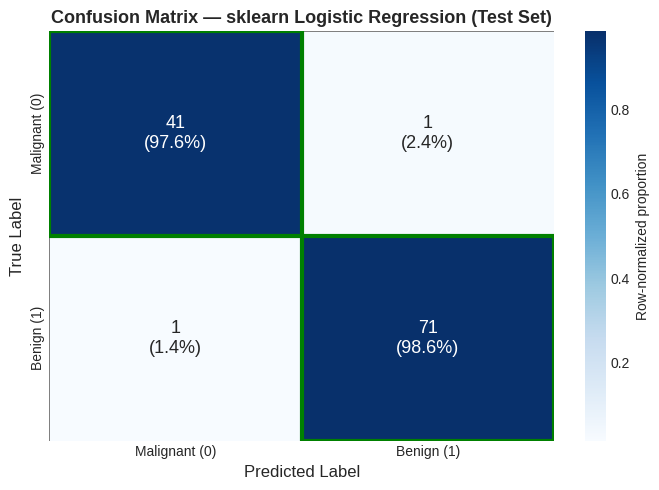

TP=71, TN=41, FP=1, FN=1
Precision = 0.986
Recall    = 0.986


In [8]:
# --- Confusion Matrix Visualization ---

cm = confusion_matrix(y_test, y_pred_sk)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

# Build annotation strings: count + percentage
labels = np.array([[f"{count}\n({pct:.1%})" for count, pct in zip(row_c, row_n)]
                   for row_c, row_n in zip(cm, cm_norm)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Row-normalized proportion'},
            ax=ax, annot_kws={"size": 13})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — sklearn Logistic Regression (Test Set)', fontsize=13, fontweight='bold')

# Highlight diagonal (correct predictions)
for i in range(2):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='green', lw=3))

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Precision = {tp/(tp+fp):.3f}")
print(f"Recall    = {tp/(tp+fn):.3f}")

In [9]:
# --- Full Classification Report ---
# sklearn's classification_report prints per-class and macro/weighted averages

print("Classification Report — sklearn Logistic Regression")
print("=" * 60)
print(classification_report(y_test, y_pred_sk,
                             target_names=['Malignant (0)', 'Benign (1)']))
print("=" * 60)
print("""
How to read this report:
  precision  : Of all samples predicted as this class, how many were correct?
  recall     : Of all true samples of this class, how many did we find?
  f1-score   : Harmonic mean of precision and recall (best=1, worst=0)
  support    : Number of true samples in this class in the test set

  macro avg    : Simple average over classes (treats classes equally)
  weighted avg : Average weighted by class support (accounts for imbalance)
""")

Classification Report — sklearn Logistic Regression
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


How to read this report:
  precision  : Of all samples predicted as this class, how many were correct?
  recall     : Of all true samples of this class, how many did we find?
  f1-score   : Harmonic mean of precision and recall (best=1, worst=0)
  support    : Number of true samples in this class in the test set

  macro avg    : Simple average over classes (treats classes equally)
  weighted avg : Average weighted by class support (accounts for imbalance)



## Theory — ROC Curve & AUC

The metrics we computed so far depend on a fixed threshold (0.5). The **ROC (Receiver Operating Characteristic) curve** evaluates classifier performance across *all possible thresholds*, giving a threshold-independent view.

### Definitions

$$\text{TPR (True Positive Rate / Recall / Sensitivity)} = \frac{TP}{TP + FN}$$

$$\text{FPR (False Positive Rate / Fall-out)} = \frac{FP}{FP + TN}$$

At each threshold $t \in [0, 1]$:
- If $t$ is very low, almost everything is predicted positive: TPR is high but FPR is also high.
- If $t$ is very high, almost nothing is predicted positive: FPR is low but TPR is also low.

The ROC curve plots TPR vs FPR as the threshold varies from 1 to 0.

### Area Under the Curve (AUC)

The **AUC** summarizes the ROC curve in a single number:

| AUC | Interpretation |
|---|---|
| $= 0.5$ | Random classifier (diagonal line) — no discriminative power |
| $0.5 < \text{AUC} < 1$ | Better than random — the higher the better |
| $= 1.0$ | Perfect classifier — no false positives at any threshold |

Probabilistic interpretation: AUC is the probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative example.

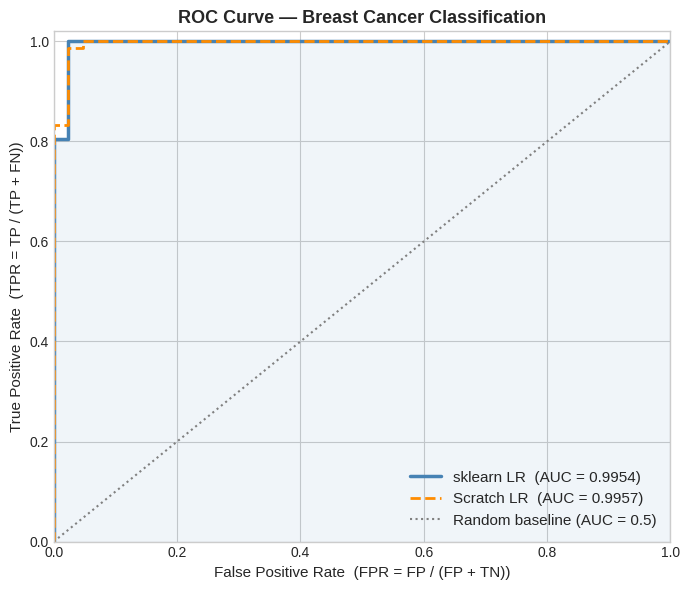

In [10]:
# --- ROC Curve Plot ---

# Get predicted probabilities (not hard labels) for ROC
y_proba_sk = sk_model.predict_proba(X_test)[:, 1]     # P(y=1 | X)
y_proba_scratch = scratch_model.predict_proba(X_test)  # shape (m,)

fpr_sk,     tpr_sk,     _ = roc_curve(y_test, y_proba_sk)
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_proba_scratch)

auc_sk     = auc(fpr_sk,     tpr_sk)
auc_scratch = auc(fpr_scratch, tpr_scratch)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_sk,     tpr_sk,     color='steelblue', lw=2.5,
        label=f'sklearn LR  (AUC = {auc_sk:.4f})')
ax.plot(fpr_scratch, tpr_scratch, color='darkorange', lw=2, linestyle='--',
        label=f'Scratch LR  (AUC = {auc_scratch:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='Random baseline (AUC = 0.5)')

# Mark the point corresponding to default threshold 0.5
default_fpr_idx = np.argmin(np.abs(fpr_sk - (1 - sk_model.score(X_test, y_test))))

ax.fill_between(fpr_sk, tpr_sk, alpha=0.08, color='steelblue')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate  (FPR = FP / (FP + TN))', fontsize=11)
ax.set_ylabel('True Positive Rate  (TPR = TP / (TP + FN))', fontsize=11)
ax.set_title('ROC Curve — Breast Cancer Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

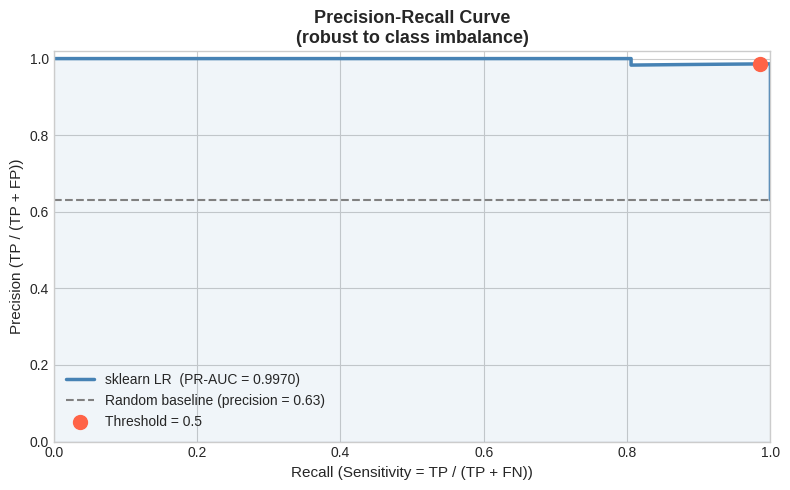

Note: This dataset is relatively balanced (~63% benign).
For heavily imbalanced datasets (e.g., 1% fraud), the PR curve
reveals classifier weaknesses that the ROC curve hides.


In [11]:
# --- Precision-Recall Curve ---
# Especially useful for imbalanced datasets:
# ROC curves can look optimistic when negatives vastly outnumber positives.
# The PR curve focuses on the minority (positive) class.

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba_sk)
pr_auc = auc(recall_vals, precision_vals)

# Baseline: random classifier precision = fraction of positives
baseline_precision = np.mean(y_test == 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(recall_vals, precision_vals, color='steelblue', lw=2.5,
        label=f'sklearn LR  (PR-AUC = {pr_auc:.4f})')
ax.axhline(y=baseline_precision, color='gray', lw=1.5, linestyle='--',
           label=f'Random baseline (precision = {baseline_precision:.2f})')

# Mark operating point at threshold 0.5
thresh_idx = np.argmin(np.abs(pr_thresholds - 0.5))
ax.scatter(recall_vals[thresh_idx], precision_vals[thresh_idx],
           s=100, color='tomato', zorder=5, label=f'Threshold = 0.5')

ax.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
ax.set_xlabel('Recall (Sensitivity = TP / (TP + FN))', fontsize=11)
ax.set_ylabel('Precision (TP / (TP + FP))', fontsize=11)
ax.set_title('Precision-Recall Curve\n(robust to class imbalance)', fontsize=13, fontweight='bold')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Note: This dataset is relatively balanced (~63% benign).")
print("For heavily imbalanced datasets (e.g., 1% fraud), the PR curve")
print("reveals classifier weaknesses that the ROC curve hides.")

PCA explained variance: PC1=44.4%, PC2=18.9%
2D model test accuracy: 94.7%  (vs 98.2% with all 30 features)


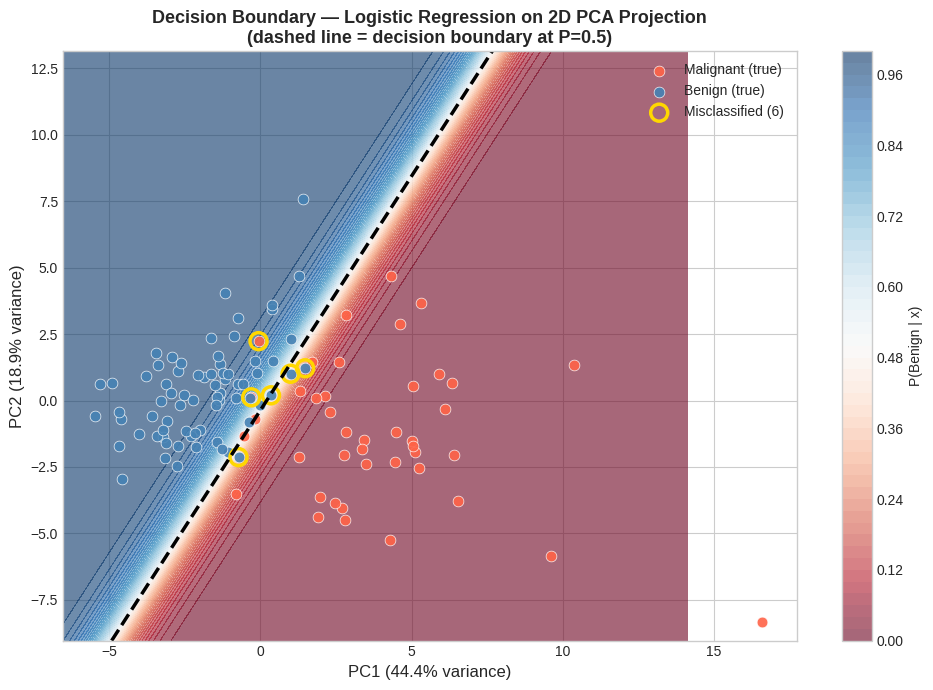

In [12]:
# --- Decision Boundary Visualization via PCA (2D) ---
# We reduce 30 features to 2 principal components so we can visualize
# the decision boundary in a 2D plane.

# Fit PCA on training data
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Train logistic regression in 2D space
lr_2d = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_2d.fit(X_train_2d, y_train)
acc_2d = lr_2d.score(X_test_2d, y_test)

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"2D model test accuracy: {acc_2d*100:.1f}%  (vs {acc_sk*100:.1f}% with all 30 features)")

# Create a meshgrid to evaluate decision probabilities across the 2D space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = lr_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))

# Filled contour (probability heatmap)
contourf = ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
plt.colorbar(contourf, ax=ax, label='P(Benign | x)')

# Decision boundary at P = 0.5
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')

# Scatter test points (true labels)
colors = {0: 'tomato', 1: 'steelblue'}
labels_map = {0: 'Malignant (true)', 1: 'Benign (true)'}
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=colors[cls], edgecolors='white', linewidths=0.5,
               s=60, alpha=0.9, label=labels_map[cls])

# Mark misclassified points
y_pred_2d = lr_2d.predict(X_test_2d)
misclassified = y_pred_2d != y_test
ax.scatter(X_test_2d[misclassified, 0], X_test_2d[misclassified, 1],
           s=150, facecolors='none', edgecolors='gold', linewidths=2.5,
           label=f'Misclassified ({misclassified.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Decision Boundary — Logistic Regression on 2D PCA Projection\n'
             '(dashed line = decision boundary at P=0.5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

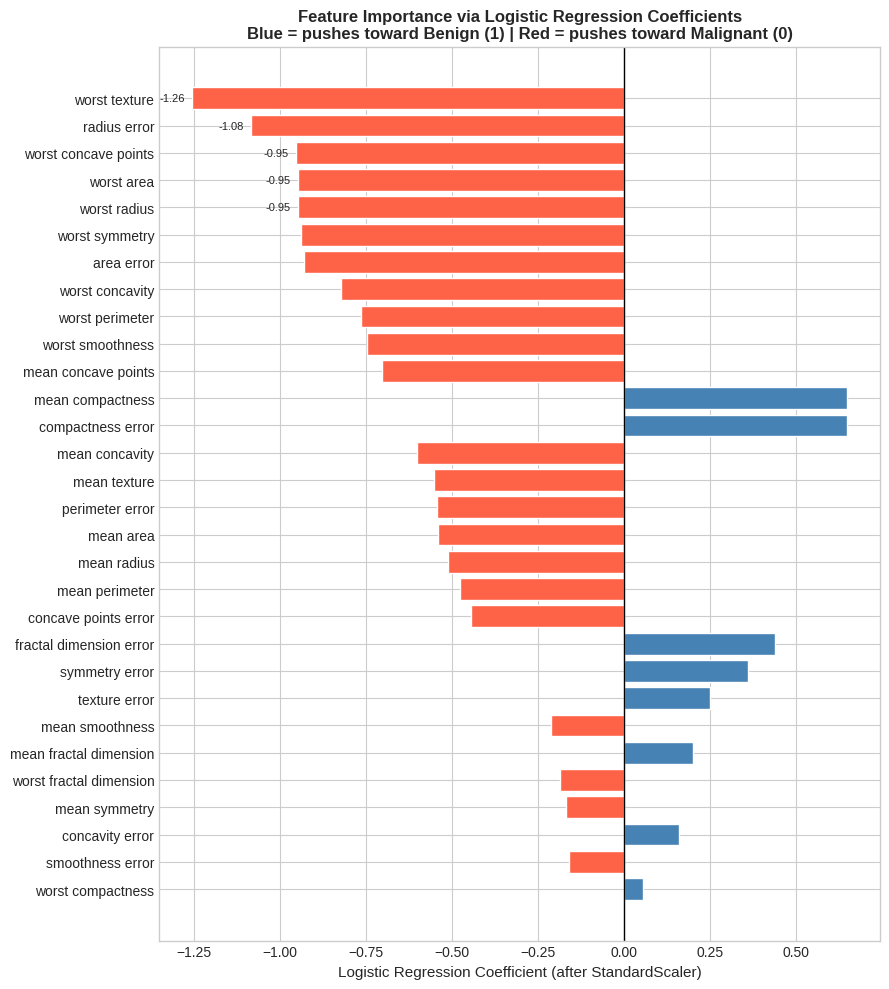

Top 5 most influential features:
             feature  coefficient
       worst texture    -1.255088
        radius error    -1.082965
worst concave points    -0.953686
          worst area    -0.947756
        worst radius    -0.947616


In [13]:
# --- Feature Importance via Logistic Regression Coefficients ---
# After StandardScaler, all features are on the same scale,
# so |coefficient| directly reflects each feature's influence.

coefs = sk_model.coef_[0]  # shape (n_features,)
coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': coefs,
    'abs_coef'   : np.abs(coefs)
}).sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')

ax.axvline(x=0, color='black', lw=1)
ax.set_xlabel('Logistic Regression Coefficient (after StandardScaler)', fontsize=11)
ax.set_title('Feature Importance via Logistic Regression Coefficients\n'
             'Blue = pushes toward Benign (1) | Red = pushes toward Malignant (0)',
             fontsize=12, fontweight='bold')

# Annotate top 5 most influential features
top5 = coef_df.nlargest(5, 'abs_coef')
for _, row in top5.iterrows():
    offset = 0.02 if row['coefficient'] >= 0 else -0.02
    ax.text(row['coefficient'] + offset, row['feature'],
            f"{row['coefficient']:.2f}", va='center', fontsize=8,
            ha='left' if row['coefficient'] >= 0 else 'right')

plt.tight_layout()
plt.show()

print("Top 5 most influential features:")
print(coef_df.nlargest(5, 'abs_coef')[['feature','coefficient']].to_string(index=False))

## Theory — Regularization in Logistic Regression

### The Overfitting Problem

Like all parametric models, logistic regression can overfit — especially when there are many features or when features are correlated. The model memorizes training data by assigning very large coefficients, which leads to poor generalization.

### L2 Regularization (Ridge)

Adds a penalty proportional to the **sum of squared weights**:

$$J_{L2}(\mathbf{w}) = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)} \log(\hat{p}^{(i)}) + (1-y^{(i)}) \log(1-\hat{p}^{(i)})\right] + \frac{\lambda}{2} \|\mathbf{w}\|_2^2$$

Effect: **shrinks all coefficients** toward zero smoothly. Stable, differentiable, keeps all features.

### L1 Regularization (Lasso)

Adds a penalty proportional to the **sum of absolute weights**:

$$J_{L1}(\mathbf{w}) = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)} \log(\hat{p}^{(i)}) + (1-y^{(i)}) \log(1-\hat{p}^{(i)})\right] + \lambda \|\mathbf{w}\|_1$$

Effect: **drives many coefficients exactly to zero** → automatic feature selection. Useful when you suspect only a few features are relevant.

### The `C` Parameter in sklearn

sklearn uses $C = \frac{1}{\lambda}$ — the **inverse** of regularization strength:

| $C$ value | Effect |
|---|---|
| Very small (e.g., 0.001) | Strong regularization → simpler model, may underfit |
| $C = 1$ (default) | Moderate regularization |
| Very large (e.g., 100) | Weak regularization → complex model, may overfit |

> **Rule of thumb:** use cross-validation to select $C$. The sweet spot lies between underfitting and overfitting.

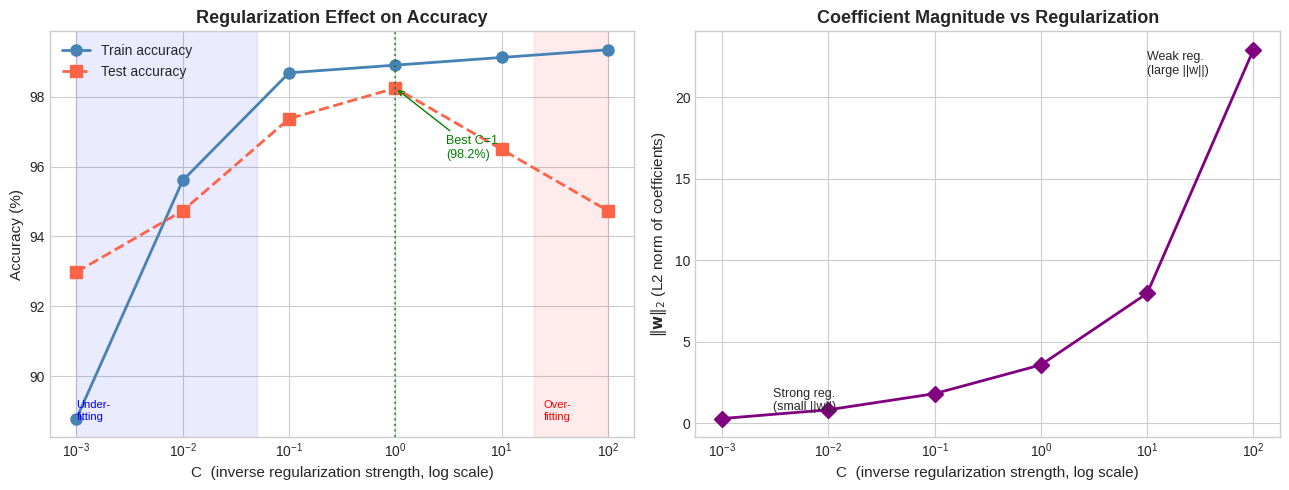

Best C = 1 → Test accuracy = 98.25%


In [14]:
# --- Effect of Regularization Strength (C parameter) ---

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_accs = []
test_accs  = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=5000, random_state=42, solver='lbfgs')
    model.fit(X_train, y_train)
    train_accs.append(model.score(X_train, y_train))
    test_accs.append(model.score(X_test,  y_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Accuracy vs C ---
ax = axes[0]
ax.semilogx(C_values, [a*100 for a in train_accs], 'o-', color='steelblue',
            lw=2, markersize=8, label='Train accuracy')
ax.semilogx(C_values, [a*100 for a in test_accs],  's--', color='tomato',
            lw=2, markersize=8, label='Test accuracy')

best_C = C_values[np.argmax(test_accs)]
best_test = max(test_accs) * 100
ax.axvline(x=best_C, color='green', lw=1.5, linestyle=':', alpha=0.7)
ax.annotate(f'Best C={best_C}\n({best_test:.1f}%)', xy=(best_C, best_test),
            xytext=(best_C * 3, best_test - 2),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='green'), color='green')

ax.set_xlabel('C  (inverse regularization strength, log scale)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Regularization Effect on Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate underfitting / overfitting regions
ax.axvspan(C_values[0], 0.05, alpha=0.08, color='blue', label='_underfitting')
ax.axvspan(20, C_values[-1], alpha=0.08, color='red', label='_overfitting')
ax.text(0.001, ax.get_ylim()[0] + 0.5, 'Under-\nfitting', fontsize=8, color='blue')
ax.text(25, ax.get_ylim()[0] + 0.5, 'Over-\nfitting', fontsize=8, color='red')

# --- Right: Coefficient magnitudes vs C ---
ax2 = axes[1]
coef_norms = []
for C in C_values:
    model = LogisticRegression(C=C, max_iter=5000, random_state=42, solver='lbfgs')
    model.fit(X_train, y_train)
    coef_norms.append(np.linalg.norm(model.coef_[0]))

ax2.semilogx(C_values, coef_norms, 'D-', color='purple', lw=2, markersize=8)
ax2.set_xlabel('C  (inverse regularization strength, log scale)', fontsize=11)
ax2.set_ylabel(r'$\|\mathbf{w}\|_2$ (L2 norm of coefficients)', fontsize=11)
ax2.set_title('Coefficient Magnitude vs Regularization', fontsize=13, fontweight='bold')
ax2.annotate('Strong reg.\n(small ||w||)', xy=(C_values[0], coef_norms[0]),
             xytext=(0.003, coef_norms[0]+0.5), fontsize=9)
ax2.annotate('Weak reg.\n(large ||w||)', xy=(C_values[-1], coef_norms[-1]),
             xytext=(10, coef_norms[-1]-1.5), fontsize=9)

plt.tight_layout()
plt.show()

print(f"Best C = {best_C} → Test accuracy = {max(test_accs)*100:.2f}%")

## Exercises

Complete the following exercises to deepen your understanding of logistic regression. Work through them in order — each builds on the last.

---

### Exercise 1 — L1 Regularization and Feature Sparsity

Train a new logistic regression model using `solver='saga'` and `penalty='l1'` with `C=0.1`.
Compare its coefficients with those from the L2 model above:

```python
lr_l1 = LogisticRegression(solver='saga', penalty='l1', C=0.1, max_iter=5000, random_state=42)
lr_l1.fit(X_train, y_train)
```

**Questions:**
- How many coefficients are exactly zero with L1 vs L2?
- Which features does L1 keep? Do they match the most important features found in the L2 coefficient plot?
- Plot both coefficient vectors side-by-side as a bar chart.

---

### Exercise 2 — Threshold Tuning for Medical Diagnosis

Change the decision threshold from 0.5 to 0.3 using `sklearn`'s `predict_proba`:

```python
y_proba = sk_model.predict_proba(X_test)[:, 1]
y_pred_03 = (y_proba >= 0.3).astype(int)
```

**Questions:**
- Compute the confusion matrix, precision, and recall for threshold = 0.3.
- Compare with threshold = 0.5. What changed?
- In cancer detection, we label `1 = Benign` and `0 = Malignant`. If we lower the threshold, do we catch more malignant tumors (fewer false negatives) or fewer? Why?
- Is there a trade-off? What does this have to do with the Precision-Recall curve?

---

### Exercise 3 — Implement Sigmoid Without scipy

Implement the sigmoid function using only NumPy and verify it produces the same results as `scipy.special.expit`:

```python
def sigmoid_numpy(z):
    # Your implementation here
    # Hint: handle numerical stability for very large/small values of z
    ...

z_test = np.array([-1000, -10, -1, 0, 1, 10, 1000])
print(sigmoid_numpy(z_test))
print(expit(z_test))
print("Max difference:", np.max(np.abs(sigmoid_numpy(z_test) - expit(z_test))))
```

**Hint:** For large positive $z$, $e^{-z} \approx 0$ so $\sigma(z) \approx 1$. For large negative $z$, you can use the equivalent form $\sigma(z) = e^z / (1 + e^z)$ to avoid overflow. Or use `np.clip`.

## Summary

### Key Takeaways

| Concept | Key Idea |
|---|---|
| **Sigmoid function** | Squashes any real value to $(0,1)$; output = $P(y=1 \mid \mathbf{x})$ |
| **Decision boundary** | Hyperplane $\mathbf{w}^T\mathbf{x}+b=0$; logistic regression is a *linear* classifier |
| **Log-loss** | Convex loss for binary classification; penalizes confident mistakes heavily |
| **Gradient descent** | Same formula as linear regression: $\nabla_w J = \frac{1}{m}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})$ |
| **Confusion matrix** | Foundation of all classification metrics (TP, TN, FP, FN) |
| **Precision vs Recall** | Precision: avoid false alarms. Recall: don't miss positives. Always context-dependent |
| **ROC / AUC** | Threshold-independent evaluation; AUC=1 is perfect, AUC=0.5 is random |
| **L1 / L2 regularization** | L1 = sparse (feature selection); L2 = shrinkage. `C = 1/λ` in sklearn |
| **Threshold tuning** | Default 0.5 is not always optimal — use domain knowledge to adjust |

### What We Used

- **Dataset**: Breast Cancer Wisconsin (569 samples, 30 features, binary target)
- **Preprocessing**: `StandardScaler` + stratified 80/20 split (from Workshops 1–7)
- **Models**: Custom `LogisticRegressionScratch` (NumPy) and `sklearn.linear_model.LogisticRegression`
- **Evaluation**: Accuracy, confusion matrix, precision, recall, F1, ROC-AUC, PR-AUC
- **Visualization**: Decision boundary via PCA, coefficient importance, regularization curves

---

### What's Next — Workshop 10: Decision Trees

Logistic regression gives us a **linear** decision boundary. But what if the true boundary is non-linear? In Workshop 10 we will study **Decision Trees** — a non-parametric, interpretable model that can capture complex, non-linear patterns by recursively partitioning the feature space. Decision trees will also be our gateway to ensemble methods (Random Forests, Gradient Boosting) in later workshops.